In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from scipy.stats import linregress



from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'



In [2]:

def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds







In [3]:
# load nino
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean()
ninoJAS = nino.where(nino.time.dt.month.isin([7,8,9])).groupby('time.year').mean()
ninoJFM = nino.where(nino.time.dt.month.isin([1,2,3])).groupby('time.year').mean()

# Precip vs SST in the west

In [4]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp)#select rev. time only
#select revtime only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))
#select west
tp_west = tp.sel(lat = slice(20,-20), lon = slice(130, 150))

tp_weights = np.cos(np.deg2rad(tp_west.lat))
tp_west_mean = global_mean(tp_west, tp_west.tp, tp_weights).rolling(time = 3, center = True).mean()


In [5]:
#compute the anomaly
tp_west_anom = anomaly(tp_west_mean, tp_weights, detrend = False)

tp_west['box_mean'] = tp_west_mean
tp_west['anom'] = tp_west_anom

In [6]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
fp = '/data/jmex/output/circulation/sst_dashed.nc'
sst = decode_time(fp)

In [7]:
#select western part
sst_west = sst.sel(lat = slice(20,-20), lon = slice(130,150), time = slice('1958-01-01', '2023-12-31') )

#compute weighted average
sst_weights = np.cos(np.deg2rad(sst_west.lat))
sst_west_mean = global_mean(sst_west, sst_west.sst_dashed, sst_weights).rolling(time = 3, center = True).mean()

In [8]:
#compute the anomaly
sst_west_anom = anomaly(sst_west_mean, sst_weights, detrend = False)

sst_west['box_mean'] = sst_west_mean
sst_west['anom'] = sst_west_anom

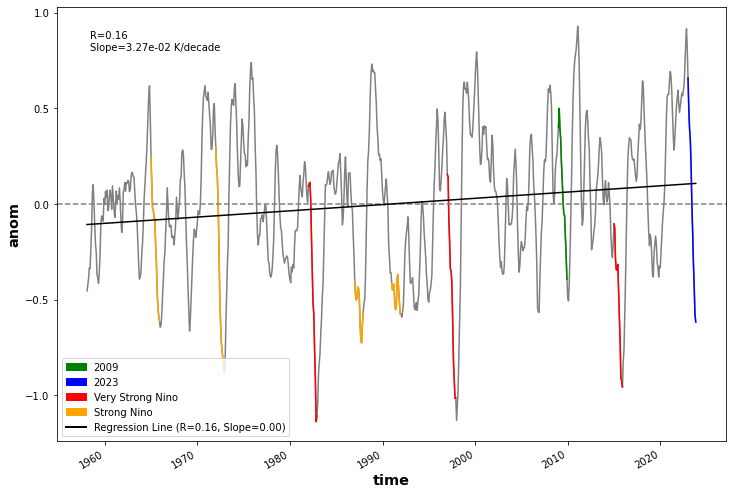

standard deviation: 0.38K


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import linregress
import numpy as np

# Filter out NaN values from sst_west.anom
sst_west_filtered = sst_west.dropna(dim='time', subset=['anom'])

# Your existing code
plt.figure(figsize=(12, 8))
plt.xlabel('Time')
plt.ylabel('SST Anom [K]')
plt.title('SST West S20N20|E130E150')

sst_west_filtered.anom.plot(color='grey')
sst_west_filtered.sel(time='2015').anom.plot(color='red')
sst_west_filtered.sel(time='1997').anom.plot(color='red')
sst_west_filtered.sel(time='1982').anom.plot(color='red')

sst_west_filtered.sel(time='1965').anom.plot(color='orange')
sst_west_filtered.sel(time='1972').anom.plot(color='orange')
sst_west_filtered.sel(time='1987').anom.plot(color='orange')
sst_west_filtered.sel(time='1991').anom.plot(color='orange')

sst_west_filtered.sel(time='2023').anom.plot(color='b')
sst_west_filtered.sel(time='2009').anom.plot(color='g')

plt.axhline(0, linestyle='--', color='grey')

# Convert time to numeric values for regression
time_numeric = np.arange(len(sst_west_filtered.time))

# Calculating regression line
slope, intercept, r_value, p_value, std_err = linregress(time_numeric, sst_west_filtered.anom.values)
regression_line = slope * time_numeric + intercept
plt.plot(sst_west_filtered.time, regression_line, color='black', label=f'Regression Line (R={r_value:.2f}, Slope={slope:.2f})')

# Add a point with green color for '2009'
plt.plot([], [], 'o', color='green', label='2009')

# Add a point with red color and marker for 'Very Strong Nino'
plt.plot([], [], 's', color='red', label='Very Strong Nino')

# Add a point with red color and marker for 'Very Strong Nino'
plt.plot([], [], 's', color='orange', label='Strong Nino')

# Create custom legend handles
handles = [
    mpatches.Patch(color='green', label='2009'),
    mpatches.Patch(color='blue', label='2023'),
    mpatches.Patch(color='red', label='Very Strong Nino'),
    mpatches.Patch(color='orange', label='Strong Nino'),    
    plt.Line2D([0], [0], color='black', lw=2, label=f'Regression Line (R={r_value:.2f}, Slope={slope:.2f})')
]

# Add legend with custom handles
plt.legend(handles=handles)

# Display r-value and slope
plt.text(0.05, 0.9, f'R={r_value:.2f}\nSlope={120*slope:.2e} K/decade', transform=plt.gca().transAxes)

plt.show()

print('standard deviation: {:.2f}K'.format(np.std(sst_west_filtered.anom).data))

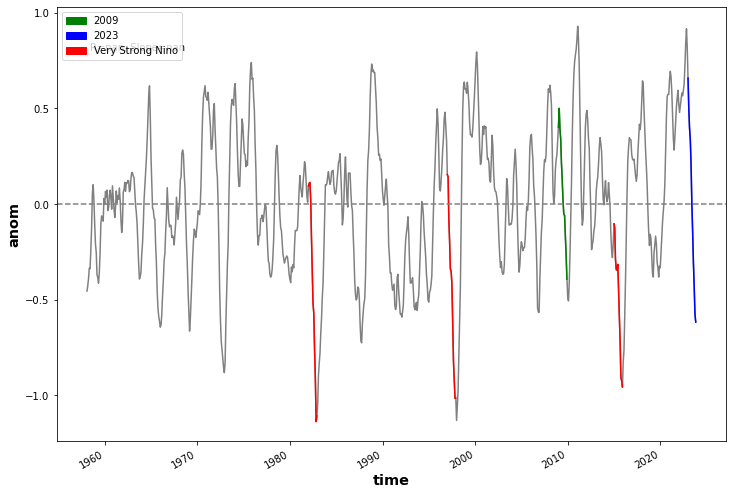

'\nThere is a increasing trend. \nDuring Enso there is a decline at the beginning of the year\nIf the base line is higher, the decline does not go down that much\nThere seems to be a section before and after 2000, which might be realted to the PDV\n'

In [10]:
plt.figure(figsize = (12,8))
plt.xlabel('Time')
plt.ylabel('SST\' Anom [K]')
plt.title('SST \' West S20N20|E130E150')

sst_west.anom.plot(color = 'grey')
sst_west.sel(time = '2015').anom.plot(color = 'red')
sst_west.sel(time = '1997').anom.plot(color = 'red')
sst_west.sel(time = '1982').anom.plot(color = 'red')
sst_west.sel(time = '2023').anom.plot(color = 'b')
sst_west.sel(time = '2009').anom.plot(color = 'g')


# Convert time to numeric values for regression
time_numeric = np.arange(len(sst_west.time))

# Calculating regression line
slope, intercept, r_value, p_value, std_err = linregress(time_numeric, sst_west.anom.values)
regression_line = slope * time_numeric + intercept
plt.plot(sst_west.time, regression_line, color='black', label=f'Regression Line (R={r_value:.2f}, Slope={slope:.2f})')


plt.axhline(0, linestyle = '--', color = 'grey')
          
# Add a point with green color for '2009'
plt.plot([], [], 'o', color='green', label='2009')

# Add a point with red color and marker for 'Very Strong Nino'
plt.plot([], [], 's', color='red', label='Very Strong Nino')

# Create custom legend handles
handles = [
    mpatches.Patch(color='green', label='2009'),
    mpatches.Patch(color='blue', label='2023'),
    mpatches.Patch(color='red', label='Very Strong Nino')
]

# Add legend with custom handles
plt.legend(handles=handles)
plt.text(0.05, 0.9, f'R={r_value:.2f}, Slope={slope:.2f}', transform=plt.gca().transAxes)


plt.show()


"""
There is a increasing trend. 
During Enso there is a decline at the beginning of the year
If the base line is higher, the decline does not go down that much
There seems to be a section before and after 2000, which might be realted to the PDV
"""


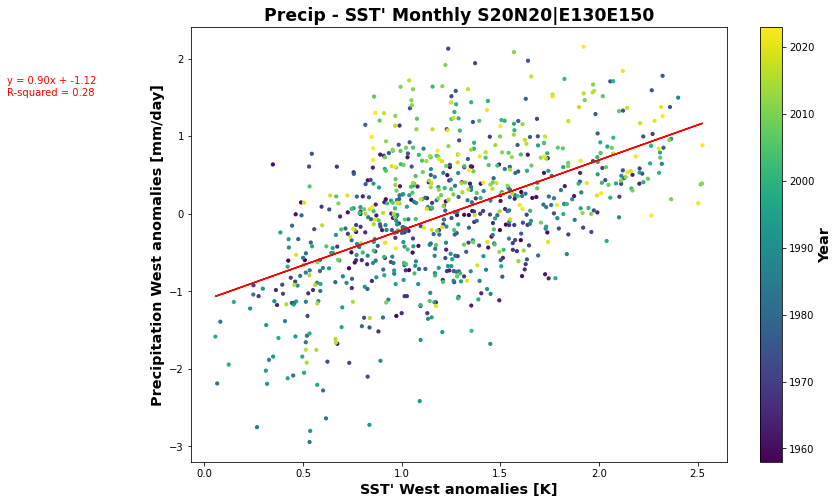

In [11]:


# Mask NaN values
valid_mask = ~np.isnan(sst_west.anom.values) & ~np.isnan(tp_west.anom.values)
sst_valid = sst_west.box_mean.values[valid_mask]
tp_valid = tp_west.anom.values[valid_mask]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)


plt.figure(figsize = (12,8))
# Create scatter plot
plt.scatter(sst_valid, tp_valid, c=sst_west.time.dt.year[valid_mask], cmap='viridis', s = 10)
plt.colorbar(label='Year')

# Add linear regression line
plt.plot(sst_valid, slope * sst_valid + intercept, color='red')

# Add axis labels
plt.xlabel('SST\' West anomalies [K]')
plt.ylabel('Precipitation West anomalies [mm/day]')

# Add title
plt.title('Precip - SST\' Monthly S20N20|E130E150')

# Add regression equation to the plot
plt.text(-1,1.5,
         f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_value**2:.2f}',
         color='red', verticalalignment='bottom', horizontalalignment='left')

# Show plot
plt.show()



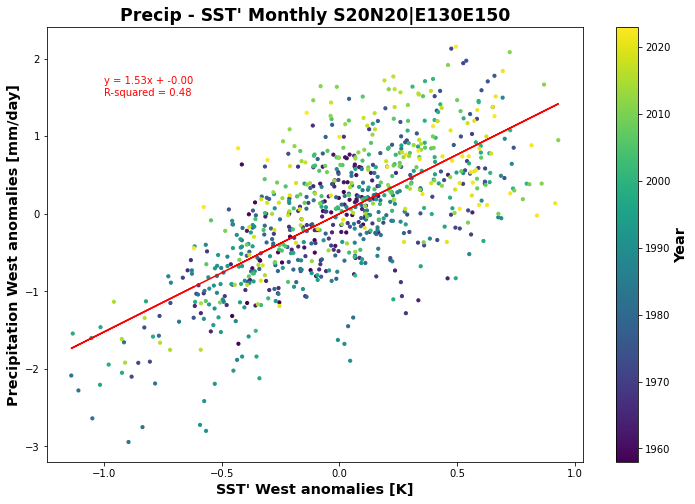

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming sst_west and tp_west are your data arrays

# Mask NaN values
valid_mask = ~np.isnan(sst_west.anom.values) & ~np.isnan(tp_west.anom.values)
sst_valid = sst_west.anom.values[valid_mask]
tp_valid = tp_west.anom.values[valid_mask]
years = sst_west.time.dt.year[valid_mask]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)

plt.figure(figsize=(12, 8))
# Create scatter plot with color for years
scatter = plt.scatter(sst_valid, tp_valid, c=years, cmap='viridis', s=10)
plt.colorbar(scatter, label='Year')

# Add linear regression line
plt.plot(sst_valid, slope * sst_valid + intercept, color='red')


# Add axis labels
plt.xlabel('SST\' West anomalies [K]')
plt.ylabel('Precipitation West anomalies [mm/day]')

# Add title
plt.title('Precip - SST\' Monthly S20N20|E130E150')

# Add regression equation to the plot
plt.text(-1, 1.5, f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_value**2:.2f}', color='red', verticalalignment='bottom', horizontalalignment='left')

# Show plot
plt.show()


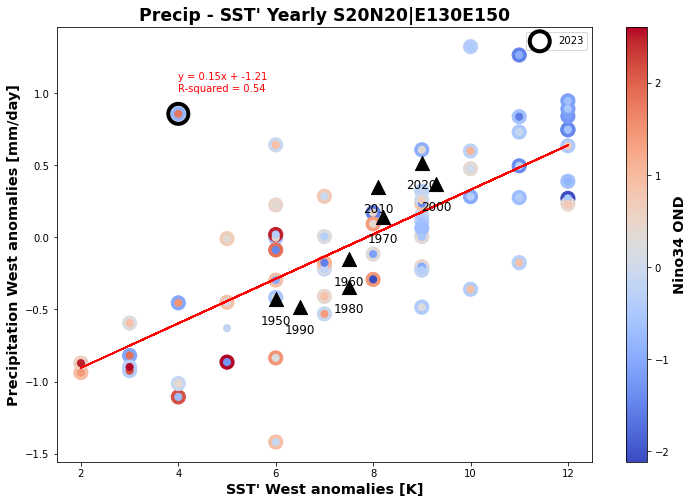

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming sst_west and tp_west are your data arrays

# Compute yearly means
sst_west_y = sst_west.resample(time='1Y').mean()
tp_west_y = tp_west.resample(time='1Y').mean()

sst_west_y = sst_west.where(sst_west.box_mean >1., drop = True).resample(time = '1Y').count()


#sst_west_y = sst_west.where(sst_west.time.dt.month.isin([1,2,3,4,5,6])).resample(time='1Y').mean()
#tp_west_y = tp_west.where(tp_west.time.dt.month.isin([1,2,3,4,5,6])).resample(time='1Y').mean()

# Mask NaN values
valid_mask = ~np.isnan(sst_west_y.box_mean.values) & ~np.isnan(tp_west_y.box_mean.values)
sst_valid = sst_west_y.box_mean.values[valid_mask]
tp_valid = tp_west_y.anom.values[valid_mask]

years = sst_west_y.time.dt.year[valid_mask]
nino34 = ninoOND.nino34[valid_mask]
nino34_prev = np.roll(ninoOND.nino34[valid_mask], shift = 1)#issue with very first year

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)

# Create scatter plot with color for years
plt.figure(figsize=(12, 8))
scatter = plt.scatter(sst_valid[1:], tp_valid[1:], s = 200, c=nino34_prev[1:], cmap='coolwarm')
scatter = plt.scatter(sst_valid, tp_valid, s = 50, c=nino34, cmap='coolwarm')

plt.scatter(sst_valid[-1], tp_valid[-1], s = 400, facecolor='none', alpha=1, edgecolor = 'k', linewidth = 4, label = '2023')
#plt.scatter(sst_valid[-15], tp_valid[-15], s = 100, facecolor='none', alpha=1, edgecolor = 'g', linewidth = 4, label = '2009')

plt.colorbar(scatter, label='Nino34 OND')

# Add linear regression line
plt.plot(sst_valid, slope * sst_valid + intercept, color='red')

# Compute means for each decade and plot as large triangles
decades = np.arange(years.min() // 10 * 10, years.max() // 10 * 10 + 10, 10)
for decade in decades:
    decade_mask = (years >= decade) & (years < decade + 10)
    sst_decade_mean = np.mean(sst_valid[decade_mask])
    tp_decade_mean = np.mean(tp_valid[decade_mask])
    plt.scatter(sst_decade_mean, tp_decade_mean, marker='^', s=200, c='black', edgecolors='black', linewidth=1)
    plt.text(sst_decade_mean, tp_decade_mean-0.2, str(decade), color='black', fontsize=12, ha='center', va='bottom')

# Add axis labels
plt.xlabel('SST\' West anomalies [K]')
plt.ylabel('Precipitation West anomalies [mm/day]')

# Add title
plt.title('Precip - SST\' Yearly S20N20|E130E150')

# Add regression equation to the plot
plt.text(4, 1., f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_value**2:.2f}', color='red', verticalalignment='bottom', horizontalalignment='left')

# Show plot
plt.legend()
plt.show()




In [14]:
sst_west.sel(time = slice('2022','2023')).where(sst_west.box_mean >1., drop = True).box_mean.resample(time= '1Y').count()



<xarray.DataArray 'box_mean' (time: 2)>
array([12,  4])
Coordinates:
  * time     (time) datetime64[ns] 2022-12-31 2023-12-31

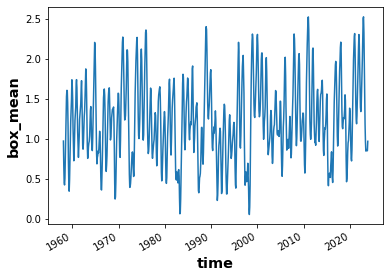

In [15]:
sst_west.box_mean.plot()

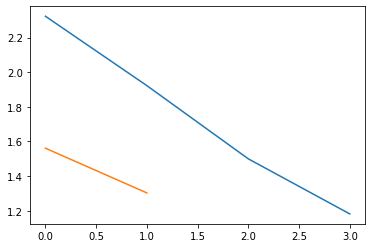

In [16]:
plt.plot(sst_west.where(sst_west.box_mean>1).sel(time = '2023').box_mean, label = '2023')
plt.plot(sst_west.where(sst_west.box_mean>1).sel(time = '2015').box_mean, label = '2015')




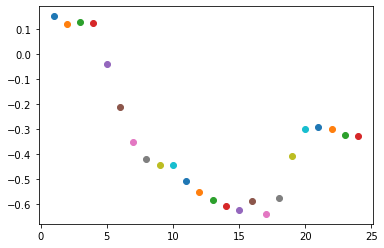

In [17]:

for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 1), tp_west_y.anom)
    plt.scatter(i, corr[0,1])
for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 0), tp_west_y.anom)
    plt.scatter(12+i, corr[0,1])


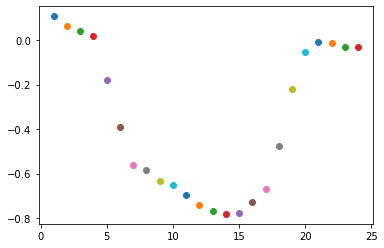

In [18]:
tp_west_y = tp_west.where(tp_west.time.dt.month.isin([1,2,3,4,5,6])).resample(time='1Y').mean()


for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 1), tp_west_y.anom)
    plt.scatter(i, corr[0,1])
for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 0), tp_west_y.anom)
    plt.scatter(12+i, corr[0,1])


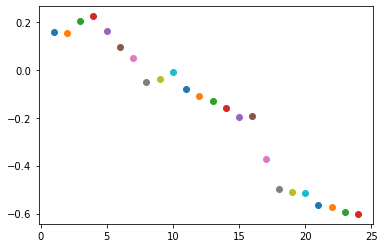

In [19]:
tp_west_y = tp_west.where(tp_west.time.dt.month.isin([7,8,9,10,11,12])).resample(time='1Y').mean()


for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 1), tp_west_y.anom)
    plt.scatter(i, corr[0,1])
for i in range(1,13):
    corr = np.corrcoef(np.roll(nino.nino34.where(nino.time.dt.month == i, drop = True), shift = 0), tp_west_y.anom)
    plt.scatter(12+i, corr[0,1])


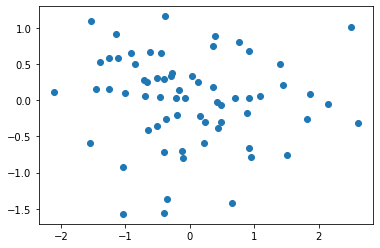

In [20]:
plt.scatter(np.roll(ninoOND.nino34, shift = 1), tp_west_y.anom)

In [21]:
tp_west_y.anom

<xarray.DataArray 'anom' (time: 66)>
array([-0.26258612, -0.20987008,  0.33026493,  0.14680751,  0.29749388,
       -0.41780452, -0.29609752, -0.91884028, -0.75551307, -0.29858658,
       -0.26228852, -0.18125407,  0.25807507,  0.15848932, -1.57243164,
        0.08259063,  0.15882289,  0.66235427, -0.59123101, -0.06681733,
        0.74654534, -0.35038115, -0.21572845,  0.03594832, -1.56582615,
       -0.05377256,  0.06336933,  0.27872758, -0.71463294, -0.7895873 ,
        0.21295049,  0.11969473,  0.03986589, -0.59698927, -0.65609542,
       -0.80178084, -0.37987069,  0.03551719,  0.1037934 , -1.3629022 ,
       -0.3143714 ,  0.58671906,  0.92305409,  0.30148722, -0.70202837,
        0.50197938, -0.03017887,  0.80437546,  0.03381399,  0.68640796,
        0.52457967,  0.37596946,  0.06346475,  1.09603373,  0.65302005,
        0.8899224 ,  0.33483673, -1.41684302,  1.00947774,  1.16282243,
        0.65278862,  0.02629143,  0.1786678 ,  0.58724284,  0.24676813,
        0.49593086])
Coordinates:
  * time     (time) datetime64[ns] 1958-12-31 1959-12-31 ... 2023-12-31

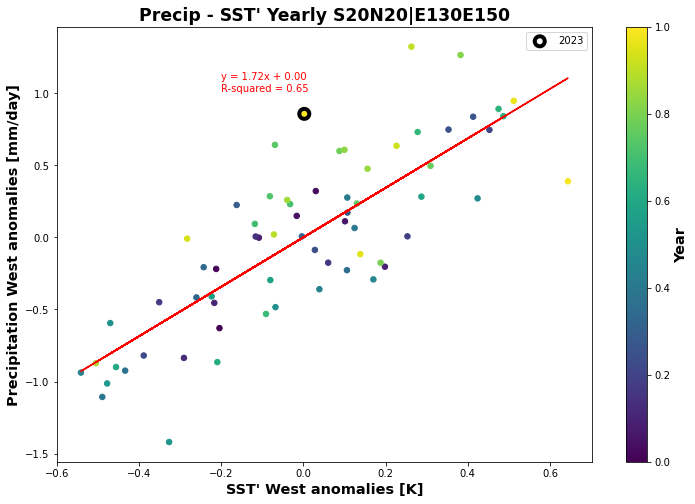

In [22]:
sst_west_y = sst_west.resample(time='1Y').mean()
tp_west_y = tp_west.resample(time='1Y').mean()

# Mask NaN values
valid_mask = ~np.isnan(sst_west_y.anom.values) & ~np.isnan(tp_west_y.anom.values)
sst_valid = sst_west_y.anom.values[valid_mask]
tp_valid = tp_west_y.anom.values[valid_mask]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)


plt.figure(figsize = (12,8))
# Create scatter plot
plt.scatter(sst_valid, tp_valid, c=sst_west_y.time.dt.year[valid_mask], cmap='viridis', s = 30)
plt.scatter(sst_valid[-1], tp_valid[-1], s = 100, facecolor='none', alpha=1, edgecolor = 'k', linewidth = 4, label = '2023')

plt.colorbar(label='Year')



# Add linear regression line
plt.plot(sst_valid, slope * sst_valid + intercept, color='red')

# Add axis labels
plt.xlabel('SST\' West anomalies [K]')
plt.ylabel('Precipitation West anomalies [mm/day]')

# Add title
plt.title('Precip - SST\' Yearly S20N20|E130E150')

# Add regression equation to the plot
plt.text(-0.2,1.,
         f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_value**2:.2f}',
         color='red', verticalalignment='bottom', horizontalalignment='left')

# Show plot
plt.legend()
plt.show()




In [23]:
sst_valid

array([-0.20432409, -0.21237019,  0.02999143, -0.0163982 ,  0.10111216,
       -0.10846567,  0.19820577, -0.21691985, -0.290816  , -0.11629894,
        0.06010393, -0.35096199,  0.2530203 ,  0.45244959, -0.38865163,
        0.02778713,  0.35290266,  0.41281393,  0.10699055, -0.16253968,
       -0.00383548, -0.26042096, -0.24281939,  0.10576417, -0.43380397,
       -0.48943373,  0.12428568,  0.10665474,  0.03881199, -0.54143082,
        0.17012478,  0.4236092 , -0.06804956, -0.47005334, -0.32679572,
       -0.47763149, -0.22336268, -0.08056032,  0.28692574, -0.4559748 ,
       -0.20959187,  0.48645929,  0.47461448,  0.27776688, -0.09113695,
       -0.11824171, -0.03238741, -0.08176862, -0.06926248,  0.12984787,
        0.30913888,  0.08762496,  0.18761621,  0.38217871,  0.09978923,
        0.15592102, -0.03957557, -0.50498677, -0.07192479,  0.26265977,
        0.22638015, -0.28293826,  0.13836032,  0.51158202,  0.64338196,
        0.00199681])

# Precip vs circulation

## W500

In [24]:
fp = '/data/jmex/output/circulation/W_w500.nc'
W_w500 = xr.open_dataset(fp).sel(time = slice('1958', '2023'))

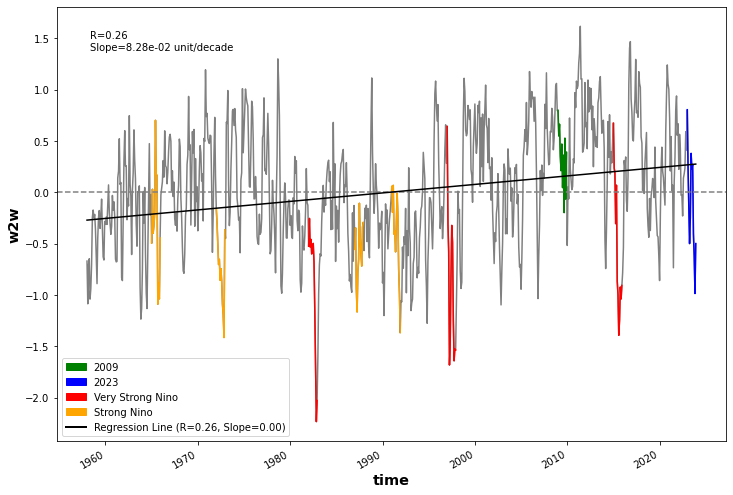

standard deviation: 0.60 unit


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import linregress
import numpy as np

# Filter out NaN values from W_w500.w2w
W_w500_filtered = W_w500.dropna(dim='time', subset=['w2w'])

# Your existing code
plt.figure(figsize=(12, 8))
plt.xlabel('Time')
plt.ylabel('SST w2w [K]')
plt.title('SST West S20N20|E130E150')

W_w500_filtered.w2w.plot(color='grey')
W_w500_filtered.sel(time='2015').w2w.plot(color='red')
W_w500_filtered.sel(time='1997').w2w.plot(color='red')
W_w500_filtered.sel(time='1982').w2w.plot(color='red')

W_w500_filtered.sel(time='1965').w2w.plot(color='orange')
W_w500_filtered.sel(time='1972').w2w.plot(color='orange')
W_w500_filtered.sel(time='1987').w2w.plot(color='orange')
W_w500_filtered.sel(time='1991').w2w.plot(color='orange')

W_w500_filtered.sel(time='2023').w2w.plot(color='b')
W_w500_filtered.sel(time='2009').w2w.plot(color='g')

plt.axhline(0, linestyle='--', color='grey')

# Convert time to numeric values for regression
time_numeric = np.arange(len(W_w500_filtered.time))

# Calculating regression line
slope, intercept, r_value, p_value, std_err = linregress(time_numeric, W_w500_filtered.w2w.values)
regression_line = slope * time_numeric + intercept
plt.plot(W_w500_filtered.time, regression_line, color='black', label=f'Regression Line (R={r_value:.2f}, Slope={slope:.2f})')

# Add a point with green color for '2009'
plt.plot([], [], 'o', color='green', label='2009')

# Add a point with red color and marker for 'Very Strong Nino'
plt.plot([], [], 's', color='red', label='Very Strong Nino')

# Add a point with red color and marker for 'Very Strong Nino'
plt.plot([], [], 's', color='orange', label='Strong Nino')

# Create custom legend handles
handles = [
    mpatches.Patch(color='green', label='2009'),
    mpatches.Patch(color='blue', label='2023'),
    mpatches.Patch(color='red', label='Very Strong Nino'),
    mpatches.Patch(color='orange', label='Strong Nino'),    
    plt.Line2D([0], [0], color='black', lw=2, label=f'Regression Line (R={r_value:.2f}, Slope={slope:.2f})')
]

# Add legend with custom handles
plt.legend(handles=handles)

# Display r-value and slope
plt.text(0.05, 0.9, f'R={r_value:.2f}\nSlope={120*slope:.2e} unit/decade', transform=plt.gca().transAxes)

plt.show()

print('standard deviation: {:.2f} unit'.format(np.std(W_w500_filtered.w2w).data))
# maybe tather than the std of all take the std of a low frequency component representative for natural variablity

No handles with labels found to put in legend.


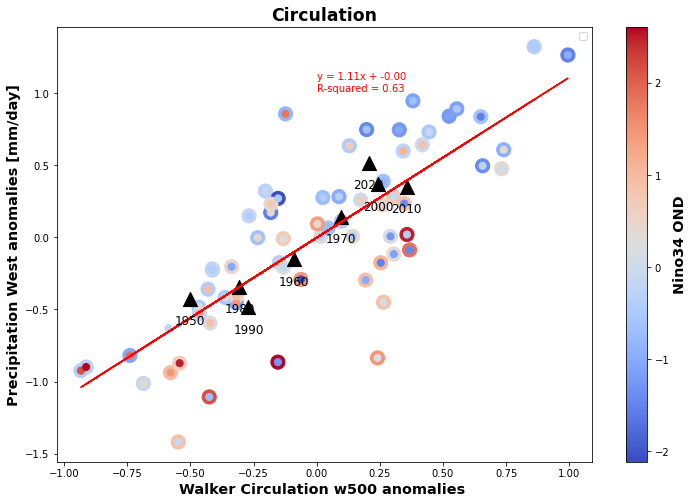

In [26]:
W_w500_y = W_w500.resample(time='1Y').mean()
tp_west_y = tp_west.resample(time='1Y').mean()
#W_w500_y = W_w500.where(W_w500.time.dt.month.isin([1,2,3,4,5,6])).resample(time='1Y').mean()
#tp_west_y = tp_west.where(tp_west.time.dt.month.isin([1,2,3,4,5,6])).resample(time='1Y').mean()


# Mask NaN values
valid_mask = ~np.isnan(W_w500_y.w2w.values) & ~np.isnan(tp_west_y.anom.values)


W_valid = W_w500_y.w2w.values[valid_mask]
tp_valid = tp_west_y.anom.values[valid_mask]


years = W_w500_y.time.dt.year[valid_mask]
nino34 = ninoOND.nino34[valid_mask]
nino34_prev = np.roll(ninoOND.nino34[valid_mask], shift = 1)#issue with very first year



# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(W_valid, tp_valid)


plt.figure(figsize = (12,8))
# Create scatter plot
#plt.scatter(W_valid, tp_valid, c=W_w500_y.time.dt.year[valid_mask], cmap='viridis', s = 30)
scatter = plt.scatter(W_valid[1:], tp_valid[1:], s = 200, c=nino34_prev[1:], cmap='coolwarm')
scatter = plt.scatter(W_valid, tp_valid, s = 50, c=nino34, cmap='coolwarm')


plt.colorbar(scatter, label='Nino34 OND')

#plt.scatter(W_valid[-1], tp_valid[-1], s = 100, facecolor='none', alpha=1, edgecolor = 'k', linewidth = 4, label = '2023')
#plt.scatter(W_valid[-15], tp_valid[-15], s = 100, facecolor='none', alpha=1, edgecolor = 'g', linewidth = 4, label = '2009')




# Compute means for each decade and plot as large triangles
decades = np.arange(years.min() // 10 * 10, years.max() // 10 * 10 + 10, 10)
for decade in decades:
    decade_mask = (years >= decade) & (years < decade + 10)
    W_decade_mean = np.mean(W_valid[decade_mask])
    tp_decade_mean = np.mean(tp_valid[decade_mask])
    plt.scatter(W_decade_mean, tp_decade_mean, marker='^', s=200, c='black', edgecolors='black', linewidth=1)
    plt.text(W_decade_mean, tp_decade_mean-0.2, str(decade), color='black', fontsize=12, ha='center', va='bottom')



# Add linear regression line
plt.plot(W_valid, slope * W_valid + intercept, color='red')

# Add axis labels
plt.xlabel('Walker Circulation w500 anomalies ')
plt.ylabel('Precipitation West anomalies [mm/day]')

# Add title
plt.title('Circulation')

# Add regression equation to the plot
plt.text(0,1.,
         f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_value**2:.2f}',
         color='red', verticalalignment='bottom', horizontalalignment='left')

# Show plot
plt.legend()
plt.show()

In [27]:
W_w500.w.plot()
plt.plot(W_w500.sel(time = '2015').w.time, W_w500.sel(time = '2015').w.values, color = 'r')
plt.plot(W_w500.sel(time = '1997').w.time, W_w500.sel(time = '1997').w.values, color = 'r')
plt.plot(W_w500.sel(time = '1982').w.time, W_w500.sel(time = '1982').w.values, color = 'r')
plt.plot(W_w500.sel(time = '2009').w.time, W_w500.sel(time = '2009').w.values, color = 'g')

AttributeError: 'Dataset' object has no attribute 'w'

In [1]:
W_w500.w2w.std(
)

NameError: name 'W_w500' is not defined

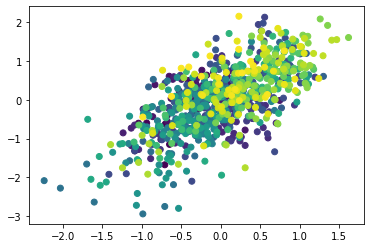

In [33]:
plt.scatter(W_w500.w2w.values, tp_west.anom.values, c = sst_west.anom.time)

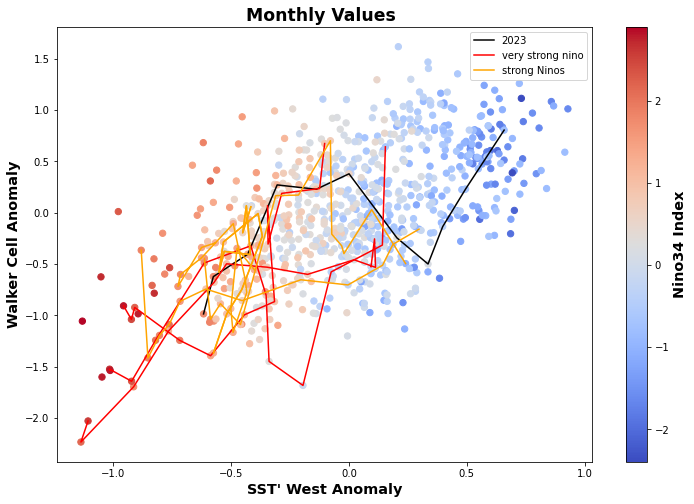

In [42]:
plt.figure(figsize = (12,8))
plt.plot(sst_west.sel(time = '2023').anom.values, W_w500.sel(time = '2023').w2w.values, label = '2023', color = 'k')


plt.plot(sst_west.sel(time = '2015').anom.values, W_w500.sel(time = '2015').w2w.values, c= 'r')
plt.plot(sst_west.sel(time = '1997').anom.values, W_w500.sel(time = '1997').w2w.values, c= 'r')
plt.plot(sst_west.sel(time = '1982').anom.values, W_w500.sel(time = '1982').w2w.values, c= 'r', label = 'very strong nino')

#plt.plot(sst_west.sel(time = '2009').anom.values, W_w500.sel(time = '2009').w2w.values,c = 'g', label = '2009')

strong_ninos = [1965, 1972,1987, 1991]
for s in strong_ninos:
    if True: pass
    plt.plot(sst_west.sel(time = str(s)).anom.values, W_w500.sel(time = str(s)).w2w.values, c= 'orange')

plt.plot(sst_west.sel(time = '1991').anom.values, W_w500.sel(time = '1991').w2w.values, c= 'orange', label = 'strong Ninos')



cbar = plt.scatter(sst_west.anom.values, W_w500.w2w.values, c = nino.nino34, cmap = 'coolwarm', s= 40)
plt.colorbar(cbar, label = 'Nino34 Index')

#make look good

plt.title('Monthly Values ')
plt.xlabel('SST\' West Anomaly')
plt.ylabel('Walker Cell Anomaly')
plt.legend()

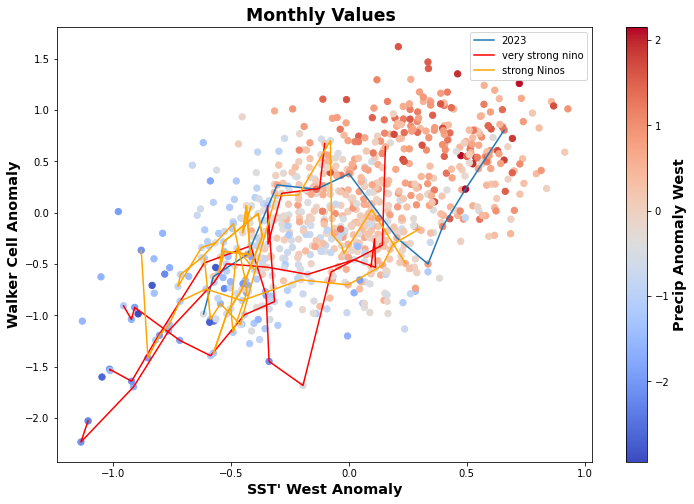

In [44]:
plt.figure(figsize = (12,8))
plt.plot(sst_west.sel(time = '2023').anom.values, W_w500.sel(time = '2023').w2w.values, label = '2023')


plt.plot(sst_west.sel(time = '2015').anom.values, W_w500.sel(time = '2015').w2w.values, c= 'r')
plt.plot(sst_west.sel(time = '1997').anom.values, W_w500.sel(time = '1997').w2w.values, c= 'r')
plt.plot(sst_west.sel(time = '1982').anom.values, W_w500.sel(time = '1982').w2w.values, c= 'r', label = 'very strong nino')

#plt.plot(sst_west.sel(time = '2009').anom.values, W_w500.sel(time = '2009').w2w.values, c= 'g', label = '2009')


strong_ninos = [1965, 1972,1987, 1991]

for s in strong_ninos:
    if True: 
        plt.plot(sst_west.sel(time = str(s)).anom.values, W_w500.sel(time = str(s)).w2w.values, c= 'orange')

plt.plot(sst_west.sel(time = '1991').anom.values, W_w500.sel(time = '1991').w2w.values, c= 'orange', label = 'strong Ninos')


cbar = plt.scatter(sst_west.anom.values, W_w500.w2w.values, c = tp_west.anom, cmap = 'coolwarm', s= 40)
plt.colorbar(cbar, label = 'Precip Anomaly West')

#make look good

plt.title('Monthly Values ')
plt.xlabel('SST\' West Anomaly')
plt.ylabel('Walker Cell Anomaly')
plt.legend()

In [ ]:
# function to deal with nan
import numpy as np

def compute_correlation(array1, array2):
    # Check for NaN values
    nan_indices = np.isnan(array1) | np.isnan(array2)

    # Remove NaN values
    array1_cleaned = array1[~nan_indices]
    array2_cleaned = array2[~nan_indices]

    # Compute correlation coefficient
    correlation_coefficient = np.corrcoef(array1_cleaned, array2_cleaned)
    return correlation_coefficient

# Example usage:
# Replace `sst_west.anom.values` and `tp_west.anom.values` with your actual data arrays
correlation_matrix = compute_correlation(sst_west.anom.values, tp_west.anom.values)
print(correlation_matrix)


In [ ]:
print(np.corrcoef(sst_west.anom.values, tp_west.anom.values))
print(np.corrcoef(sst_west.anom.values, W_w500.w.values))
print(np.corrcoef(tp_west.anom.values, W_w500.w.values))

# Mutliple Regression Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


# Sample data (replace with your actual data)
tp = tp_valid/np.linalg.norm(tp_valid)
sst = sst_valid/np.linalg.norm(sst_valid)
W = W_valid/np.linalg.norm(W_valid)

# Reshape the data for sklearn
X = np.column_stack((sst, W))
y = tp


# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Print coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Calculate R-squared value
r_squared = model.score(X, y)
print("R-squared:", r_squared)

# Visualize data and hyperplane
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(sst, W, tp, color='red', label='Data')
ax.scatter(sst[-1], W[-1], tp[-1], color='k',s = 100, label='Data')
ax.scatter(sst[-9], W[-9], tp[-9], color='blue',s = 100, label='Data')
ax.scatter(sst[-27], W[-27], tp[-27], color='blue',s = 100, label='Data')
ax.scatter(sst[-42], W[-42], tp[-42], color='blue',s = 100, label='Data')

#ax.scatter(tp[-15], sst[-15], W[-15], color='green',s = 100, label='Data')





# Create meshgrid for hyperplane
W_range = np.linspace(min(W), max(W), 10)
sst_range = np.linspace(min(sst), max(sst), 10)
sst_mesh, W_mesh = np.meshgrid(sst_range, W_range)
tp_pred = model.intercept_ + model.coef_[0]*sst_mesh + model.coef_[1]*W_mesh

# Plot hyperplane
ax.plot_surface(sst_mesh, W_mesh, tp_pred, alpha=0.5, color='blue')

#mask = (W>0)&(W<0.1)
#ax.scatter(tp[mask], sst[mask], W[mask], color='green',s = 100, label='Data')

# Set labels and title
ax.set_xlabel('sst')
ax.set_ylabel('W')
ax.set_zlabel('tp')
ax.set_title('Linear Regression Model')

# Show plot
plt.show()


In [ ]:
print(np.corrcoef(tp, sst))
print(np.corrcoef(tp, W))
print(np.corrcoef(W, sst))

In [ ]:
import numpy as np
import xarray as xr
import statsmodels.api as sm

# Generate sample data
# Assuming sst, W, and tp are xarray DataArrays
# Replace this with your actual data
sst = xr.DataArray(sst, dims='time')
W = xr.DataArray(W, dims='time')
tp = xr.DataArray(tp, dims='time')

# Convert xarray DataArrays to pandas DataFrames
sst_df = sst.to_dataframe(name='sst')
W_df = W.to_dataframe(name='W')
tp_df = tp.to_dataframe(name='tp')

# Combine into one DataFrame
data = pd.concat([sst_df, W_df, tp_df], axis=1)

# Step 1: Regression between SST and TP
X = data[['sst']]
y = data['tp']
X = sm.add_constant(X)  # Add a constant term to the predictor
model = sm.OLS(y, X).fit()

# Step 2: Calculate Residuals
residuals = model.resid

# Step 3: Regression between Residuals and W
X_res = data[['W']]
X_res = sm.add_constant(X_res)  # Add a constant term to the predictor
model_res = sm.OLS(residuals, X_res).fit()

# Print results
print("Regression between SST and TP:")
print(model.summary())

print("\nRegression between Residuals and W:")
print(model_res.summary())


In [ ]:
import numpy as np
import xarray as xr
import statsmodels.api as sm

# Generate sample data
# Assuming sst, W, and tp are xarray DataArrays
# Replace this with your actual data
sst = xr.DataArray(sst, dims='time')
W = xr.DataArray(W, dims='time')
tp = xr.DataArray(tp, dims='time')

# Convert xarray DataArrays to pandas DataFrames
sst_df = sst.to_dataframe(name='sst')
W_df = W.to_dataframe(name='W')
tp_df = tp.to_dataframe(name='tp')

# Combine into one DataFrame
data = pd.concat([sst_df, W_df, tp_df], axis=1)

# Step 1: Regression between SST and TP
X = data[['W']]
y = data['tp']
X = sm.add_constant(X)  # Add a constant term to the predictor
model = sm.OLS(y, X).fit()

# Step 2: Calculate Residuals
residuals = model.resid

# Step 3: Regression between Residuals and W
X_res = data[['sst']]
X_res = sm.add_constant(X_res)  # Add a constant term to the predictor
model_res = sm.OLS(residuals, X_res).fit()

# Print results
print("Regression between SST and TP:")
print(model.summary())

print("\nRegression between Residuals and W:")
print(model_res.summary())


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Assuming W and sst are xarray DataArrays
# Replace this with your actual data
#W = xr.DataArray(W)  # Sample data for demonstration
#sst = xr.DataArray(sst)  # Sample data for demonstration

# Compute the cross-correlation function (CCF) at different lags
max_lag = 10  # Maximum lag to consider
lags = np.arange(-max_lag, max_lag + 1)
ccf_values = [np.correlate(W, sst.shift(time=lag).fillna(0), 'valid')[0] for lag in lags]

# Plot the lag correlation plot
plt.figure(figsize=(8, 6))
plt.plot(lags, ccf_values, marker='o', linestyle='-')
plt.title('Lag Correlation Plot between W and SST')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.grid(True)
plt.show()

In [ ]:
-0.64*-0.79